In [26]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import tiktoken as tk
import pprint
import matplotlib.pyplot as plt

In [2]:
!pip install gutenbergpy

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 35.7 MB/s eta 0:00:00
  Created wheel for httpsproxy-urllib2: filename=httpsproxy_urllib2-1.0-py3-none-any.whl size=29251 sha256=35089e6c82d64a234b073f59c48d10d1a82bcd6d22cfdbd69ca32d67789fee25
  Stored in directory: /root/.cache/pip/wheels/c6/c5/98/dd27835c8319362f1cef163409f43df38d54f084500fad428c
Successfully built httpsproxy-urllib2


In [20]:
import gutenbergpy.textget
import random

# Pre-norm vs Post-norm

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
device

'cuda'

In [6]:
tokenizer = tk.get_encoding("gpt2")

In [7]:
#lets implement compact class for normalization
class LayerNorm(nn.Module):
  def __init__(self, emb_size):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_size))
    self.shift = nn.Parameter(torch.zeros(emb_size))

  def forward(self, x):
    mean = x.mean(keepdim=True, dim=-1)
    variance = x.var(keepdim=True, dim=-1, unbiased=False)
    norm_x = (x - mean)/torch.sqrt(variance + self.eps)
    return self.scale * norm_x + self.shift

class MultiHeadAttention(nn.Module):
  def __init__(self, dim_in, dim_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert (dim_out % num_heads == 0), "dim_out must be divisible by num_heads"

    self.dim_out = dim_out # final merged context vector embedding size
    self.num_heads = num_heads
    self.head_dim = dim_out//num_heads # embedding size of context vector in single head
    self.w_query = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.w_key = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.w_value = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.out_proj = torch.nn.Linear(dim_out, dim_out) # transform merged context_vectors into similar dimension size vectors
    self.dropout = torch.nn.Dropout(dropout)
    self.register_buffer(
        'mask',
        torch.triu(torch.ones(context_length, context_length), diagonal=1)
    )

  def forward(self, x):
    batch_size, num_tokens, dim_in = x.shape
    queries = self.w_query(x)
    keys = self.w_key(x)
    values = self.w_value(x)  #shape (batch_size, num_tokens, dim_out)

    queries = queries.view(batch_size, num_tokens, self.num_heads, self.head_dim)
    keys = keys.view(batch_size, num_tokens, self.num_heads, self.head_dim)
    values = values.view(batch_size, num_tokens, self.num_heads, self.head_dim) #shape (batch_size, num_tokens, num_heads, head_dim)

    queries = queries.transpose(1,2)
    keys = keys.transpose(1,2)
    values = values.transpose(1,2) #shape (batch_size, num_heads, num_tokens, head_dim)

    attention_scores = queries @ keys.transpose(2,3)
    attention_scores.masked_fill_(self.mask.bool()[:num_tokens,:num_tokens], -torch.inf)

    attention_weights = torch.softmax(attention_scores/keys.shape[-1]**0.5, dim=-1)
    attention_weights = self.dropout(attention_weights)

    context_vectors = (attention_weights @ values).transpose(1,2) #transposing axis 1,2  since we have to merge the context vectors by num_heads and head_dim, so required shape will now be (batch_size, num_tokens, num_heads, head_dim)
    context_vectors = context_vectors.contiguous().view(batch_size, num_tokens, self.dim_out)

    context_vectors = self.out_proj(context_vectors)

    return context_vectors

class GeLU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x,3))
    ))

class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg['emb_size'], 4 * cfg['emb_size']),
        GeLU(),
        nn.Linear(4 * cfg['emb_size'], cfg['emb_size'])
    )

  def forward(self, x):
    return self.layers(x)



In [8]:
GPT_CONFIG = {
    'emb_size':768,
    'context_length':1024,
    'vocab_size':50257,
    'num_heads':12,
    'num_layers':18,
    'drop_rate':0.1,
    'qkv_bias':False,
}

In [27]:
class GPTDataset(Dataset):
  def __init__(self, text, tokenizer, max_length, stride):
    self.inputs = []
    self.targets = []

    encoded_text = tokenizer.encode(text)

    for i in range(0,len(encoded_text) - max_length, stride):
      input = encoded_text[i:i+max_length]
      target = encoded_text[i+1:i+max_length+1]

      self.inputs.append(torch.tensor(input))
      self.targets.append(torch.tensor(target))

  def __len__(self):
    return len(self.inputs)

  def __getitem__(self, index):
    return self.inputs[index], self.targets[index]

In [19]:
def download_dataset(n_books=100):
    # IDs are roughly between 1 and 70,000
    # We'll pick random IDs; note: not all IDs exist or are English
    book_ids = random.sample(range(1, 60000), n_books * 2)
    downloaded_texts = []

    for b_id in book_ids:
        try:
            # 1. Get raw text
            raw_text = gutenbergpy.textget.get_text_by_id(b_id)
            # 2. Strip Gutenberg headers/footers (CRITICAL for LLMs)
            clean_text = gutenbergpy.textget.strip_headers(raw_text)

            downloaded_texts.append(clean_text.decode('utf-8'))
            print(f"Downloaded book {b_id}")

            if len(downloaded_texts) >= n_books:
                break
        except:
            print(f"Skipping {b_id}")
            continue # Skip IDs that aren't available in text format

    return downloaded_texts

In [22]:
random.seed(10)
texts = download_dataset(n_books=3)
shuffled_texts = random.sample(texts, len(texts))
train_texts_list = shuffled_texts[:2]
val_texts_list = shuffled_texts[2:]

train_texts = tokenizer.decode([tokenizer.eot_token])[0].join(train_texts_list)
val_texts = tokenizer.decode([tokenizer.eot_token])[0].join(val_texts_list)

Downloaded book 37448
Downloaded book 2136
Downloaded book 28108


In [23]:
print(texts[0])











[Illustration: BRINKER BRINKER in footprints]




     _A man may be a scoundrel, a crook, a high-phased confidence man,
     and still work toward a great dream which will be worth far more
     than the momentary damage his swindles cost._




_Comet's Burial_

_by_ RAYMOND Z. GALLUN


Outside Tycho Station on the Moon, Jess Brinker showed Arne Copeland the
odd footprints made in the dust by explorers from Mars, fifty million
years ago. A man-made cover of clear plastic now kept them from being
trampled.

"Who hasn't heard about such prints?" Copeland growled laconically.
"There's no air or weather here to rub them out--even in eternity.
Thanks for showing a fresh-arrived greenhorn around..."

Copeland was nineteen, tough, willing to learn, but wary. His wide mouth
was usually sullen, his grey eyes a little narrowed in a face that
didn't have to be so grim. Back in Iowa he had a girl. Frances. But love
had to wait, for he needed the Moon the way Peary had once needed the
No

In [28]:
print(f"Tokens in train set: {len(tokenizer.encode(train_texts))}")
print(f"Tokens in val set: {len(tokenizer.encode(val_texts))}")

Tokens in train set: 34961
Tokens in val set: 28295


In [29]:
train_dataset = GPTDataset(train_texts, tokenizer, max_length=256, stride=256)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, drop_last=True, num_workers=0)

val_dataset = GPTDataset(val_texts, tokenizer, max_length=256, stride=256)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, drop_last=True, num_workers=0)

In [30]:
def ce_batch_loss_calc(input_batch, target_batch, model, device):
  """
  ARGS
  input_batch: torch.tensor 2-D
  target_batch: torch.tensor 2-D
  model: GPTModel
  device: torch.device - 'cuda' or 'cpu'

  calculates cross-entropy loss for a batch
  """
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)
  logits_batch = model(input_batch)
  loss = torch.nn.functional.cross_entropy(logits_batch.flatten(0, 1), target_batch.flatten())

  return loss

In [31]:
def calc_loss_dataloader(loader, model, device, num_batches=None):
  """
  ARGS
  loader: dataloader
  model: GPTModel
  device: torch.device - 'cuda' or 'cpu'
  num_batches: integer

  calculates mean cross entropy loss across all the batches of the dataloader
  """
  total_loss = 0
  if len(loader) == 0:
    return float('nan')
  elif num_batches is None:
    num_batches = len(loader)
  elif num_batches < 0:
    num_batches = float('nan')
  else:
    num_batches = min(num_batches, len(loader))

  for i, (x, y) in enumerate(loader):
    if i < num_batches:
      loss = ce_batch_loss_calc(x, y, model, device)
      total_loss += loss
    else:
      break

  return total_loss/num_batches

In [32]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [34]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter=None):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_dataloader(train_loader, model, device, eval_iter)
    val_loss = calc_loss_dataloader(val_loader, model, device, eval_iter)
  model.train()

  return train_loss, val_loss

In [35]:
def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text)
  encoded_tensor = torch.tensor(encoded).unsqueeze(0)
  return encoded_tensor

def token_ids_to_text(tokens, tokenizer):
  token_list = tokens.squeeze(0).tolist()
  decoded = tokenizer.decode(token_list)
  return decoded

In [37]:
def generate_text_tokens(model, inp_tokens, max_tokens, context_size):
  for _ in range(max_tokens):
    cropped_tokens = inp_tokens[:,-context_size:]
    with torch.no_grad():
      logits = model(cropped_tokens)

    logits = logits[:,-1,:]
    prob = torch.softmax(logits, dim=-1)
    token_id = torch.argmax(prob, dim=-1, keepdim=True)
    inp_tokens = torch.cat((inp_tokens, token_id), dim=1)

  return inp_tokens

In [38]:
def generate_and_print_sample(model, start_context, tokenizer, device):
  model.eval()
  context_size = model.trf_blocks[0].mha.mask.shape[0] ##model.pos_emb.shape[0]
  encoded_text = text_to_token_ids(start_context, tokenizer).to(device)
  with torch.no_grad():
    op_tokens = generate_text_tokens(model, encoded_text, max_tokens=50, context_size=context_size)
  decoded_text = token_ids_to_text(op_tokens, tokenizer)

  print(decoded_text.replace('\n',' '))
  model.train()

In [45]:
def train_model_simple(model, train_loader, val_loader, device, optimizer, epochs, eval_freq, eval_iter, start_context, tokenizer):
  train_loss_arr, val_loss_arr, track_tokens_seen = [], [], []
  global_step, tokens_seen = -1, 0
  global_grad_norms = []

  for epoch in range(epochs):
    model.train()
    for x, y in train_loader:
      model.zero_grad()
      train_loss = ce_batch_loss_calc(x, y, model, device)
      train_loss.backward()
      total_norm = 0
      for name, p in model.named_parameters():
        if p.requires_grad:
          param_norm = torch.norm(p.grad)
          total_norm += param_norm ** 2
      total_norm = total_norm ** 0.5
      global_grad_norms.append(total_norm)
      optimizer.step()
      tokens_seen += x.numel()
      global_step += 1

      if global_step % eval_freq == 0:
        train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
        train_loss_arr.append(train_loss)
        val_loss_arr.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        print(f'Train loss after epoch {epoch} (Step: {global_step}): {train_loss:.3f}')
        print(f'Val loss after epoch {epoch} (Step: {global_step}): {val_loss:.3f}')
        print(f'Number of tokens seen after epoch {epoch} (Step: {global_step})')

    generate_and_print_sample(model, start_context, tokenizer, device)

  return train_loss_arr, val_loss_arr, track_tokens_seen, global_grad_norms

In [39]:
#pre-norm transformer
class PrenormTransformer(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.layer_norm1 = LayerNorm(config['emb_size'])
    self.layer_norm2 = LayerNorm(config['emb_size'])
    self.mha = MultiHeadAttention(config['emb_size'], config['emb_size'], config['context_length'], config['drop_rate'], config['num_heads'], qkv_bias=config['qkv_bias'])
    self.ffn = FeedForward(config)
    self.dropout = nn.Dropout(config['drop_rate'])

  def forward(self, x):
    res = x
    x = self.layer_norm1(x)
    x = self.mha(x)
    x = self.dropout(x)
    x = x + res

    res = x
    x = self.layer_norm2(x)
    x = self.ffn(x)
    x = self.dropout(x)
    x = x + res

    return x

In [40]:
class GPTModelPreNorm(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.token_emb_layer = nn.Embedding(cfg['vocab_size'], cfg['emb_size'])
    self.pos_emb_layer = nn.Embedding(cfg['context_length'], cfg['emb_size'])
    self.dropout_layer = nn.Dropout(cfg['drop_rate'])
    self.trf_blocks = nn.Sequential(
        *[PrenormTransformer(cfg) for _ in range(cfg['num_layers'])]
    )
    self.final_norm = LayerNorm(cfg['emb_size'])
    self.output_layer = nn.Linear(cfg['emb_size'], cfg['vocab_size'], bias=False)

  def forward(self, inp_tokens):
    batch_size, num_tokens = inp_tokens.shape
    token_emb = self.token_emb_layer(inp_tokens)
    pos_emb = self.pos_emb_layer(
        torch.arange(num_tokens, device=inp_tokens.device)
    )
    x = token_emb + pos_emb
    x = self.dropout_layer(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.output_layer(x)

    return logits

In [46]:
import time

torch.manual_seed(123)
prenorm = GPTModelPreNorm(GPT_CONFIG).to(device)
optimizer1 = torch.optim.AdamW(prenorm.parameters(), lr=0.0004, weight_decay=0.1)

t1 = time.time()
train_losses1, val_losses1, tokens_seen1, global_grad_norms1 = train_model_simple(prenorm, train_loader, val_loader, device, optimizer1, epochs=4, eval_freq=5, eval_iter=5, start_context='Every effort moves you', tokenizer=tokenizer)
t2 = time.time()

print(f"Training time: {t2-t1}s")

Train loss after epoch 0 (Step: 0): 9.493
Val loss after epoch 0 (Step: 0): 9.519
Number of tokens seen after epoch 0 (Step: 0)
Train loss after epoch 0 (Step: 5): 8.223
Val loss after epoch 0 (Step: 5): 8.089
Number of tokens seen after epoch 0 (Step: 5)
Train loss after epoch 0 (Step: 10): 7.309
Val loss after epoch 0 (Step: 10): 7.493
Number of tokens seen after epoch 0 (Step: 10)
Train loss after epoch 0 (Step: 15): 6.924
Val loss after epoch 0 (Step: 15): 7.347
Number of tokens seen after epoch 0 (Step: 15)
Train loss after epoch 0 (Step: 20): 6.502
Val loss after epoch 0 (Step: 20): 7.495
Number of tokens seen after epoch 0 (Step: 20)
Train loss after epoch 0 (Step: 25): 6.209
Val loss after epoch 0 (Step: 25): 7.459
Number of tokens seen after epoch 0 (Step: 25)
Train loss after epoch 0 (Step: 30): 6.525
Val loss after epoch 0 (Step: 30): 7.283
Number of tokens seen after epoch 0 (Step: 30)
Train loss after epoch 0 (Step: 35): 6.492
Val loss after epoch 0 (Step: 35): 7.259
Numbe

In [47]:
#post-norm transformer
class PostnormTransformer(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.layer_norm1 = LayerNorm(config['emb_size'])
    self.layer_norm2 = LayerNorm(config['emb_size'])
    self.mha = MultiHeadAttention(config['emb_size'], config['emb_size'], config['context_length'], config['drop_rate'], config['num_heads'], qkv_bias=config['qkv_bias'])
    self.ffn = FeedForward(config)
    self.dropout = nn.Dropout(config['drop_rate'])

  def forward(self, x):
    res = x
    x = self.mha(x)
    x = self.dropout(x)
    x = x + res
    x = self.layer_norm1(x)

    res = x
    x = self.ffn(x)
    x = self.dropout(x)
    x = x + res
    x = self.layer_norm2(x)

    return x

In [48]:
class GPTModelPostNorm(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.token_emb_layer = nn.Embedding(cfg['vocab_size'], cfg['emb_size'])
    self.pos_emb_layer = nn.Embedding(cfg['context_length'], cfg['emb_size'])
    self.dropout_layer = nn.Dropout(cfg['drop_rate'])
    self.trf_blocks = nn.Sequential(
        *[PostnormTransformer(cfg) for _ in range(cfg['num_layers'])]
    )
    self.final_norm = LayerNorm(cfg['emb_size'])
    self.output_layer = nn.Linear(cfg['emb_size'], cfg['vocab_size'], bias=False)

  def forward(self, inp_tokens):
    batch_size, num_tokens = inp_tokens.shape
    token_emb = self.token_emb_layer(inp_tokens)
    pos_emb = self.pos_emb_layer(
        torch.arange(num_tokens, device=inp_tokens.device)
    )
    x = token_emb + pos_emb
    x = self.dropout_layer(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.output_layer(x)

    return logits

In [49]:
import time

torch.manual_seed(123)
postnorm = GPTModelPostNorm(GPT_CONFIG).to(device)
optimizer2 = torch.optim.AdamW(postnorm.parameters(), lr=0.0004, weight_decay=0.1)

t3 = time.time()
train_losses2, val_losses2, tokens_seen2, global_grad_norms2 = train_model_simple(postnorm, train_loader, val_loader, device, optimizer2, epochs=4, eval_freq=5, eval_iter=5, start_context='Every effort moves you', tokenizer=tokenizer)
t4 = time.time()

print(f"Training time: {t4-t3}s")

Train loss after epoch 0 (Step: 0): 9.650
Val loss after epoch 0 (Step: 0): 9.604
Number of tokens seen after epoch 0 (Step: 0)
Train loss after epoch 0 (Step: 5): 8.371
Val loss after epoch 0 (Step: 5): 8.375
Number of tokens seen after epoch 0 (Step: 5)
Train loss after epoch 0 (Step: 10): 7.487
Val loss after epoch 0 (Step: 10): 7.773
Number of tokens seen after epoch 0 (Step: 10)
Train loss after epoch 0 (Step: 15): 7.095
Val loss after epoch 0 (Step: 15): 7.568
Number of tokens seen after epoch 0 (Step: 15)
Train loss after epoch 0 (Step: 20): 6.706
Val loss after epoch 0 (Step: 20): 7.735
Number of tokens seen after epoch 0 (Step: 20)
Train loss after epoch 0 (Step: 25): 6.559
Val loss after epoch 0 (Step: 25): 7.816
Number of tokens seen after epoch 0 (Step: 25)
Train loss after epoch 0 (Step: 30): 6.818
Val loss after epoch 0 (Step: 30): 7.728
Number of tokens seen after epoch 0 (Step: 30)
Train loss after epoch 0 (Step: 35): 6.820
Val loss after epoch 0 (Step: 35): 7.614
Numbe

# **Comparison**

In [88]:
def plot_global_grad_norms(grad_norms_dict: dict, title="Global Gradient Norm Across Training Steps"):
    """
    grad_norms_dict: dict of {label: [norm values]}
    e.g. {"Pre-Norm": [...], "Post-Norm": [...]}
    """
    plt.figure(figsize=(10, 4))

    colors = {"Prenorm": "red", "Postnorm": "blue"}
    linestyles = {"Prenorm": "--", "Postnorm": ":"}

    for label, grad_norms in grad_norms_dict.items():
        grad_norms = [gn.clone().cpu().numpy() for gn in grad_norms]
        steps = range(len(grad_norms))
        color = colors.get(label, None)
        linestyle = linestyles.get(label, None)

        plt.plot(steps, grad_norms, linewidth=1.5, alpha=0.8, color=color, label=label, linestyle=linestyle)

        # rolling mean
        # window = max(1, len(grad_norms) // 50)
        # rolling_mean = [
        #     sum(grad_norms[max(0, i - window):i + 1]) / len(grad_norms[max(0, i - window):i + 1])
        #     for i in range(len(grad_norms))
        # ]
        # plt.plot(steps, rolling_mean, linewidth=0.8, color=color, label=label)

    plt.xlabel("Training Step")
    plt.ylabel("Global Gradient Norm")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

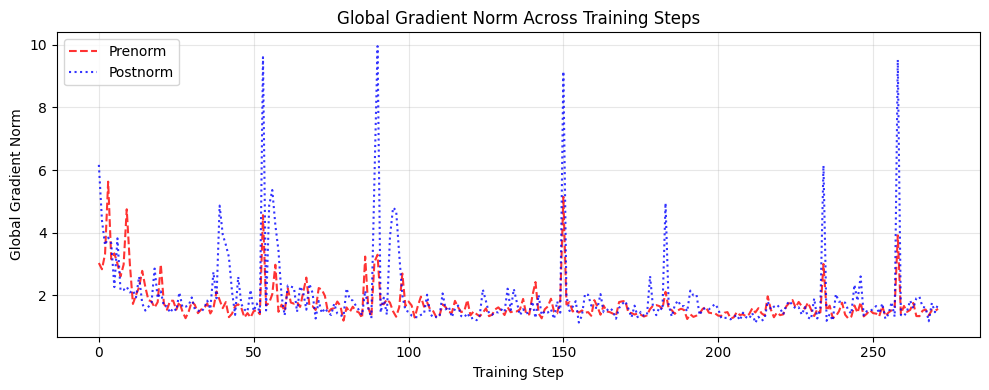

In [89]:
plot_global_grad_norms({"Prenorm": global_grad_norms1, "Postnorm": global_grad_norms2})